# Visualization of Time Series

In [3]:
from statsmodels.tsa.stattools import acf
import pandas as pd


df = pd.read_csv("https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey=demo&datatype=csv", parse_dates=['timestamp'], index_col = 'timestamp')

df.head()

,open,high,low,close,volume
timestamp,,,,,
2024-01-31,187.05,187.6500,183.14,183.66,8876055
2024-01-30,187.71,188.6500,186.77,187.87,4575058
2024-01-29,187.46,189.4600,186.05,187.14,6107908
2024-01-26,191.31,192.3896,186.16,187.42,9895941
2024-01-25,184.96,196.9000,184.83,190.43,29596239


## Line plots

/tmp/ipykernel_23137/3065378485.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['close'] = df['close'].fillna(method='ffill')


<Axes: xlabel='timestamp'>

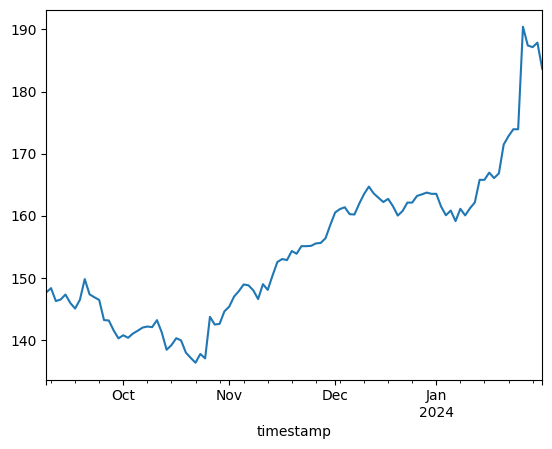

In [4]:
df = df.asfreq('B')

df['close'] = df['close'].fillna(method='ffill')

df['close'].plot()



## Seasonal decomposition plots

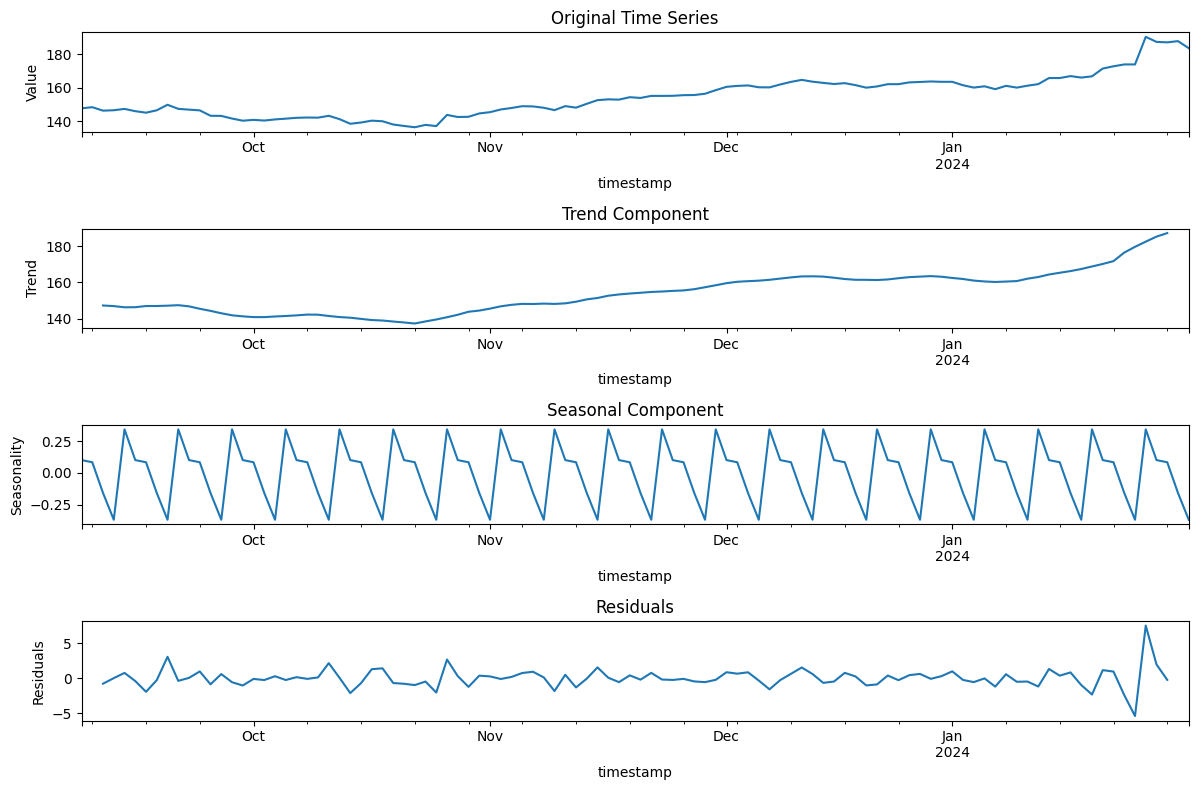

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
decomposition = seasonal_decompose(df['close'], model='additive')

# Plot the decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
df['close'].plot(ax=ax1, title='Original Time Series')
ax1.set_ylabel('Value')
decomposition.trend.plot(ax=ax2, title='Trend Component')
ax2.set_ylabel('Trend')
decomposition.seasonal.plot(ax=ax3, title='Seasonal Component')
ax3.set_ylabel('Seasonality')
decomposition.resid.plot(ax=ax4, title='Residuals')
ax4.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## Autocorrelation and partial autocorrelation plots

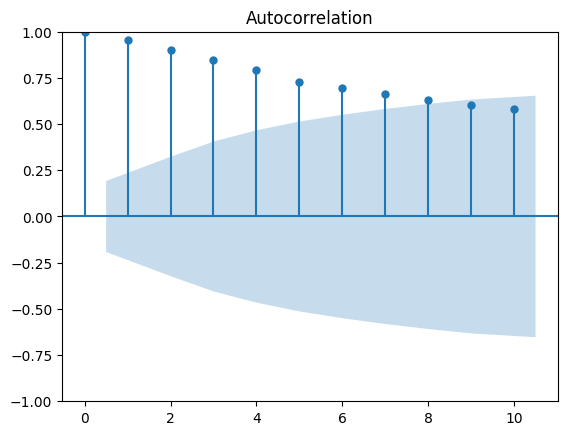

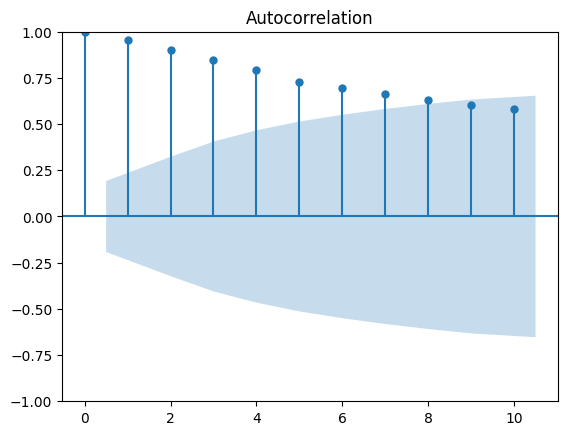

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


sm.graphics.tsa.plot_acf(df.close.dropna().squeeze(), lags=10)